In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pickle
from pathlib import Path

legend_properties = {'weight': 'bold'}
nus_blue = "#003D7C"
nus_orange = "#EF7C00"

# Nature three colors
nature_orange = "#F16C23"
nature_blue = "#2B6A99"
nature_green = "#1B7C3D"

# Morandi six colors
morandi_blue = "#046586"
morandi_green = "#28A9A1"
morandi_yellow = "#C9A77C"
morandi_orange = "#F4A016"
morandi_pink = "#F6BBC6"
morandi_red = "#E71F19"
morandi_purple = "#B08BEB"

# Others
shallow_grey = "#D3D4D3"
deep_grey = "#A6ABB6"

# Red and Blue
strong_red = "#A61C5D"
strong_blue = "#1B64A4"

# Shallow-deep pair
shallow_purple = "#EAD7EA"
deep_purple = "#BA9DB9"
shallow_cyan = "#A9D5E0"
deep_cyan = "#48C0BF"
shallow_blue = "#B6DAEC"
deep_blue = "#98CFE4"
shallow_pink = "#F5E0E5"
deep_pink = "#E5A7B6"
shallow_green = "#C2DED0"
deep_green = "#A5C6B1"

color_pairs = [
    [shallow_purple, deep_purple],
    [shallow_green, deep_green],
    [shallow_blue, deep_blue],
    [shallow_pink, deep_pink],
    [shallow_cyan, deep_cyan],
    [shallow_grey, deep_grey],
]
morandi_colors = [
    morandi_blue, morandi_green, morandi_yellow, morandi_orange,
    morandi_pink, morandi_red, morandi_purple,
]

In [2]:
# Folder containing the output files from grun_1.py and srun_1.py.
# Update this path if the scripts are executed in a different working directory.
data_folder = Path(r"/Volumes/T7/data/gst-0112-26/Appendix/Parallel_Search_K_2")
results_folder = data_folder / "Results"
results_folder.mkdir(parents=True, exist_ok=True)

# Aligned with grun_1.py and srun_1.py
K_list = [1, 2, 3, 4, 5, 6, 7, 8]
agent_num_list = np.arange(50, 850, step=50, dtype=int).tolist()

# DVs saved by the two independent-search scripts:
#   g_independent_breakthrough_fitness_across_K_size_<agent_num>
#   g_independent_breakthrough_rank_across_K_size_<agent_num>
#   g_independent_diversity_across_K_size_<agent_num>
#   g_independent_pairwise_diversity_across_K_size_<agent_num>
#   s_independent_breakthrough_fitness_across_K_size_<agent_num>
#   s_independent_breakthrough_rank_across_K_size_<agent_num>
#   s_independent_diversity_across_K_size_<agent_num>
#   s_independent_pairwise_diversity_across_K_size_<agent_num>
dv_names = [
    "breakthrough_fitness",
    "breakthrough_rank",
    "diversity",
    "pairwise_diversity",
]

In [3]:
# Load all G/S independent-search DVs.
# This cell intentionally avoids a reusable loading function, so the data structure
# remains explicit and easy to revise.

dv_data = {
    "G": {
        "breakthrough_fitness": [],
        "breakthrough_rank": [],
        "diversity": [],
        "pairwise_diversity": [],
    },
    "S": {
        "breakthrough_fitness": [],
        "breakthrough_rank": [],
        "diversity": [],
        "pairwise_diversity": [],
    },
}

for agent_num in agent_num_list:
    file_path = data_folder / "g_independent_breakthrough_fitness_across_K_size_{0}".format(agent_num)
    if not file_path.exists():
        raise FileNotFoundError("Missing file: {0}".format(file_path))
    with open(file_path, "rb") as infile:
        values = pickle.load(infile)
    if len(values) != len(K_list):
        raise ValueError("Unexpected K dimension in {0}: got {1}, expected {2}".format(file_path, len(values), len(K_list)))
    dv_data["G"]["breakthrough_fitness"].append(values)

for agent_num in agent_num_list:
    file_path = data_folder / "g_independent_breakthrough_rank_across_K_size_{0}".format(agent_num)
    if not file_path.exists():
        raise FileNotFoundError("Missing file: {0}".format(file_path))
    with open(file_path, "rb") as infile:
        values = pickle.load(infile)
    if len(values) != len(K_list):
        raise ValueError("Unexpected K dimension in {0}: got {1}, expected {2}".format(file_path, len(values), len(K_list)))
    dv_data["G"]["breakthrough_rank"].append(values)

for agent_num in agent_num_list:
    file_path = data_folder / "g_independent_diversity_across_K_size_{0}".format(agent_num)
    if not file_path.exists():
        raise FileNotFoundError("Missing file: {0}".format(file_path))
    with open(file_path, "rb") as infile:
        values = pickle.load(infile)
    if len(values) != len(K_list):
        raise ValueError("Unexpected K dimension in {0}: got {1}, expected {2}".format(file_path, len(values), len(K_list)))
    dv_data["G"]["diversity"].append(values)

for agent_num in agent_num_list:
    file_path = data_folder / "g_independent_pairwise_diversity_across_K_size_{0}".format(agent_num)
    if not file_path.exists():
        raise FileNotFoundError("Missing file: {0}".format(file_path))
    with open(file_path, "rb") as infile:
        values = pickle.load(infile)
    if len(values) != len(K_list):
        raise ValueError("Unexpected K dimension in {0}: got {1}, expected {2}".format(file_path, len(values), len(K_list)))
    dv_data["G"]["pairwise_diversity"].append(values)

for agent_num in agent_num_list:
    file_path = data_folder / "s_independent_breakthrough_fitness_across_K_size_{0}".format(agent_num)
    if not file_path.exists():
        raise FileNotFoundError("Missing file: {0}".format(file_path))
    with open(file_path, "rb") as infile:
        values = pickle.load(infile)
    if len(values) != len(K_list):
        raise ValueError("Unexpected K dimension in {0}: got {1}, expected {2}".format(file_path, len(values), len(K_list)))
    dv_data["S"]["breakthrough_fitness"].append(values)

for agent_num in agent_num_list:
    file_path = data_folder / "s_independent_breakthrough_rank_across_K_size_{0}".format(agent_num)
    if not file_path.exists():
        raise FileNotFoundError("Missing file: {0}".format(file_path))
    with open(file_path, "rb") as infile:
        values = pickle.load(infile)
    if len(values) != len(K_list):
        raise ValueError("Unexpected K dimension in {0}: got {1}, expected {2}".format(file_path, len(values), len(K_list)))
    dv_data["S"]["breakthrough_rank"].append(values)

for agent_num in agent_num_list:
    file_path = data_folder / "s_independent_diversity_across_K_size_{0}".format(agent_num)
    if not file_path.exists():
        raise FileNotFoundError("Missing file: {0}".format(file_path))
    with open(file_path, "rb") as infile:
        values = pickle.load(infile)
    if len(values) != len(K_list):
        raise ValueError("Unexpected K dimension in {0}: got {1}, expected {2}".format(file_path, len(values), len(K_list)))
    dv_data["S"]["diversity"].append(values)

for agent_num in agent_num_list:
    file_path = data_folder / "s_independent_pairwise_diversity_across_K_size_{0}".format(agent_num)
    if not file_path.exists():
        raise FileNotFoundError("Missing file: {0}".format(file_path))
    with open(file_path, "rb") as infile:
        values = pickle.load(infile)
    if len(values) != len(K_list):
        raise ValueError("Unexpected K dimension in {0}: got {1}, expected {2}".format(file_path, len(values), len(K_list)))
    dv_data["S"]["pairwise_diversity"].append(values)

dv_data["G"]["breakthrough_fitness"] = np.asarray(dv_data["G"]["breakthrough_fitness"], dtype=float)
dv_data["G"]["breakthrough_rank"] = np.asarray(dv_data["G"]["breakthrough_rank"], dtype=float)
dv_data["G"]["diversity"] = np.asarray(dv_data["G"]["diversity"], dtype=float)
dv_data["G"]["pairwise_diversity"] = np.asarray(dv_data["G"]["pairwise_diversity"], dtype=float)

dv_data["S"]["breakthrough_fitness"] = np.asarray(dv_data["S"]["breakthrough_fitness"], dtype=float)
dv_data["S"]["breakthrough_rank"] = np.asarray(dv_data["S"]["breakthrough_rank"], dtype=float)
dv_data["S"]["diversity"] = np.asarray(dv_data["S"]["diversity"], dtype=float)
dv_data["S"]["pairwise_diversity"] = np.asarray(dv_data["S"]["pairwise_diversity"], dtype=float)

# Backward-compatible variable names for ad-hoc plotting.
g_breakthrough_fitness_across_K_size = dv_data["G"]["breakthrough_fitness"].tolist()
s_breakthrough_fitness_across_K_size = dv_data["S"]["breakthrough_fitness"].tolist()
g_breakthrough_rank_across_K_size = dv_data["G"]["breakthrough_rank"].tolist()
s_breakthrough_rank_across_K_size = dv_data["S"]["breakthrough_rank"].tolist()
g_diversity_across_K_size = dv_data["G"]["diversity"].tolist()
s_diversity_across_K_size = dv_data["S"]["diversity"].tolist()
g_pairwise_diversity_across_K_size = dv_data["G"]["pairwise_diversity"].tolist()
s_pairwise_diversity_across_K_size = dv_data["S"]["pairwise_diversity"].tolist()

print("breakthrough_fitness: G {0}; S {1}".format(dv_data["G"]["breakthrough_fitness"].shape, dv_data["S"]["breakthrough_fitness"].shape))
print("breakthrough_rank: G {0}; S {1}".format(dv_data["G"]["breakthrough_rank"].shape, dv_data["S"]["breakthrough_rank"].shape))
print("diversity: G {0}; S {1}".format(dv_data["G"]["diversity"].shape, dv_data["S"]["diversity"].shape))
print("pairwise_diversity: G {0}; S {1}".format(dv_data["G"]["pairwise_diversity"].shape, dv_data["S"]["pairwise_diversity"].shape))

breakthrough_fitness: G (16, 8); S (16, 8)
breakthrough_rank: G (16, 8); S (16, 8)
diversity: G (16, 8); S (16, 8)
pairwise_diversity: G (16, 8); S (16, 8)


## G/S comparisons by K

Each cell below draws exactly one figure.

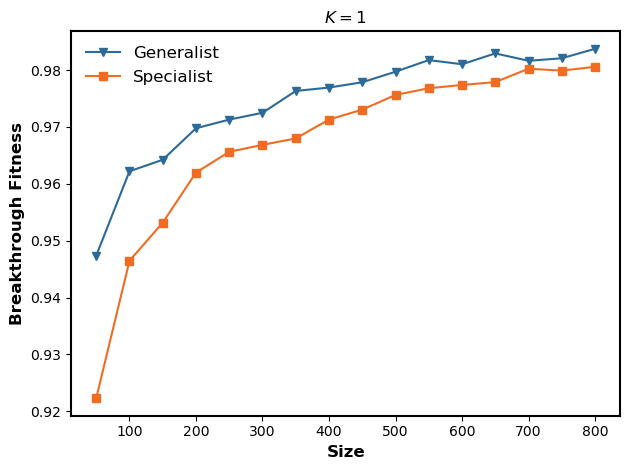

In [4]:
# Figure: Breakthrough Fitness, K=1
k_index = 0
K = 1

g_values_across_size = dv_data["G"]["breakthrough_fitness"][:, k_index]
s_values_across_size = dv_data["S"]["breakthrough_fitness"][:, k_index]

fig, ax = plt.subplots()

ax.spines["left"].set_linewidth(1.5)
ax.spines["right"].set_linewidth(1.5)
ax.spines["top"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)

ax.plot(agent_num_list, g_values_across_size, "v-", label="Generalist", color=nature_blue)
ax.plot(agent_num_list, s_values_across_size, "s-", label="Specialist", color=nature_orange)

ax.set_xlabel("Size", fontweight="bold", fontsize=12)
ax.set_ylabel("Breakthrough Fitness", fontweight="bold", fontsize=12)
ax.set_title("$K=1$")
ax.legend(frameon=False, fontsize=12)

fig.tight_layout()
fig.savefig(
    results_folder / "GS_independent_breakthrough_fitness_K_1.png",
    transparent=True,
    dpi=300,
)
plt.show()

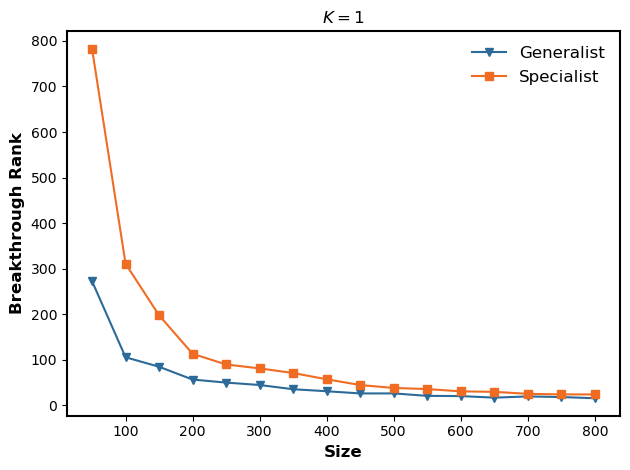

In [12]:
# Figure: Breakthrough Rank (lower is better), K=1
k_index = 0
K = 1

g_values_across_size = dv_data["G"]["breakthrough_rank"][:, k_index]
s_values_across_size = dv_data["S"]["breakthrough_rank"][:, k_index]

fig, ax = plt.subplots()

ax.spines["left"].set_linewidth(1.5)
ax.spines["right"].set_linewidth(1.5)
ax.spines["top"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)

ax.plot(agent_num_list, g_values_across_size, "v-", label="Generalist", color=nature_blue)
ax.plot(agent_num_list, s_values_across_size, "s-", label="Specialist", color=nature_orange)

ax.set_xlabel("Size", fontweight="bold", fontsize=12)
ax.set_ylabel("Breakthrough Rank", fontweight="bold", fontsize=12)
ax.set_title("$K=1$")
ax.legend(frameon=False, fontsize=12)

fig.tight_layout()
fig.savefig(
    results_folder / "GS_independent_breakthrough_rank_K_1.png",
    transparent=True,
    dpi=300,
)
plt.show()

## Uniqueness proportion by K

Each cell below draws exactly one figure.

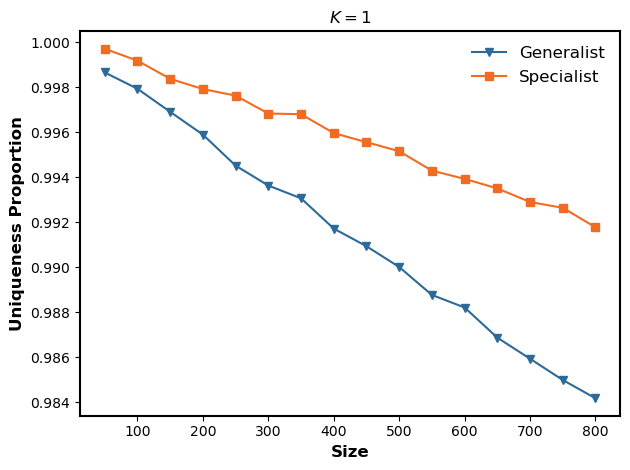

In [36]:
# Figure: Uniqueness Proportion, K=1
k_index = 0
K = 1

g_diversity_ratio = dv_data["G"]["diversity"][:, k_index] / np.asarray(agent_num_list)
s_diversity_ratio = dv_data["S"]["diversity"][:, k_index] / np.asarray(agent_num_list)

fig, ax = plt.subplots()

ax.spines["left"].set_linewidth(1.5)
ax.spines["right"].set_linewidth(1.5)
ax.spines["top"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)

ax.plot(agent_num_list, g_diversity_ratio, "v-", label="Generalist", color=nature_blue)
ax.plot(agent_num_list, s_diversity_ratio, "s-", label="Specialist", color=nature_orange)

ax.set_xlabel("Size", fontweight="bold", fontsize=12)
ax.set_ylabel("Uniqueness Proportion", fontweight="bold", fontsize=12)
ax.set_title("$K=1$")
ax.legend(frameon=False, ncol=1, fontsize=12)

fig.tight_layout()
fig.savefig(
    results_folder / "GS_independent_diversity_ratio_K_1.png",
    transparent=True,
    dpi=300,
)
plt.show()

## Heatmaps across size and K

Each cell below draws exactly one figure.

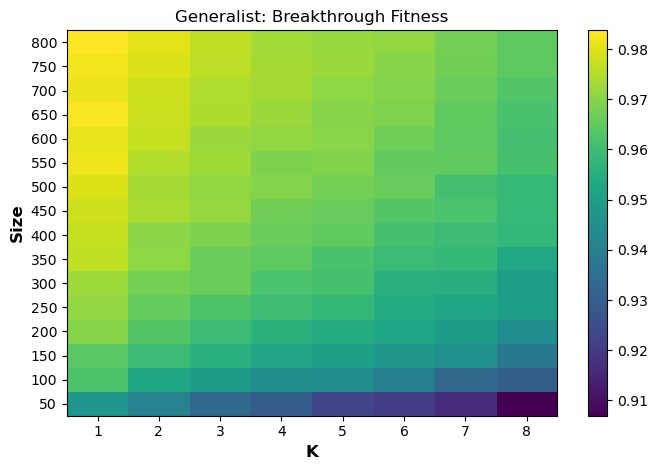

In [44]:
# Figure: Generalist heatmap - Breakthrough Fitness
z = dv_data["G"]["breakthrough_fitness"]

fig, ax = plt.subplots(figsize=(7, 4.8))

im = ax.imshow(z, aspect="auto", origin="lower")

ax.set_xticks(np.arange(len(K_list)))
ax.set_xticklabels(K_list)
ax.set_yticks(np.arange(len(agent_num_list)))
ax.set_yticklabels(agent_num_list)

ax.set_xlabel("K", fontweight="bold", fontsize=12)
ax.set_ylabel("Size", fontweight="bold", fontsize=12)
ax.set_title("Generalist: Breakthrough Fitness")

fig.colorbar(im, ax=ax)

fig.tight_layout()
fig.savefig(
    results_folder / "G_independent_breakthrough_fitness_heatmap_size_K.png",
    transparent=True,
    dpi=300,
)
plt.show()

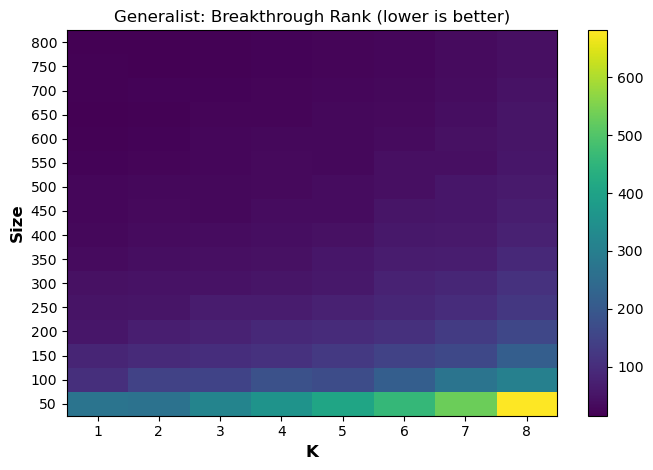

In [45]:
# Figure: Generalist heatmap - Breakthrough Rank (lower is better)
z = dv_data["G"]["breakthrough_rank"]

fig, ax = plt.subplots(figsize=(7, 4.8))

im = ax.imshow(z, aspect="auto", origin="lower")

ax.set_xticks(np.arange(len(K_list)))
ax.set_xticklabels(K_list)
ax.set_yticks(np.arange(len(agent_num_list)))
ax.set_yticklabels(agent_num_list)

ax.set_xlabel("K", fontweight="bold", fontsize=12)
ax.set_ylabel("Size", fontweight="bold", fontsize=12)
ax.set_title("Generalist: Breakthrough Rank (lower is better)")

fig.colorbar(im, ax=ax)

fig.tight_layout()
fig.savefig(
    results_folder / "G_independent_breakthrough_rank_heatmap_size_K.png",
    transparent=True,
    dpi=300,
)
plt.show()

## Mean across K

Each cell below draws exactly one figure.

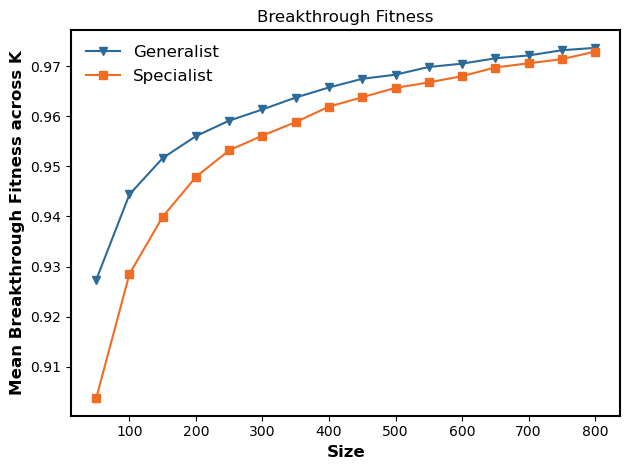

In [52]:
# Figure: Mean Breakthrough Fitness across K
g_mean_across_K = dv_data["G"]["breakthrough_fitness"].mean(axis=1)
s_mean_across_K = dv_data["S"]["breakthrough_fitness"].mean(axis=1)

fig, ax = plt.subplots()

ax.spines["left"].set_linewidth(1.5)
ax.spines["right"].set_linewidth(1.5)
ax.spines["top"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)

ax.plot(agent_num_list, g_mean_across_K, "v-", label="Generalist", color=nature_blue)
ax.plot(agent_num_list, s_mean_across_K, "s-", label="Specialist", color=nature_orange)

ax.set_xlabel("Size", fontweight="bold", fontsize=12)
ax.set_ylabel("Mean Breakthrough Fitness across K", fontweight="bold", fontsize=12)
ax.set_title("Breakthrough Fitness")
ax.legend(frameon=False, fontsize=12)

fig.tight_layout()
fig.savefig(
    results_folder / "GS_independent_breakthrough_fitness_mean_across_K.png",
    transparent=True,
    dpi=300,
)
plt.show()

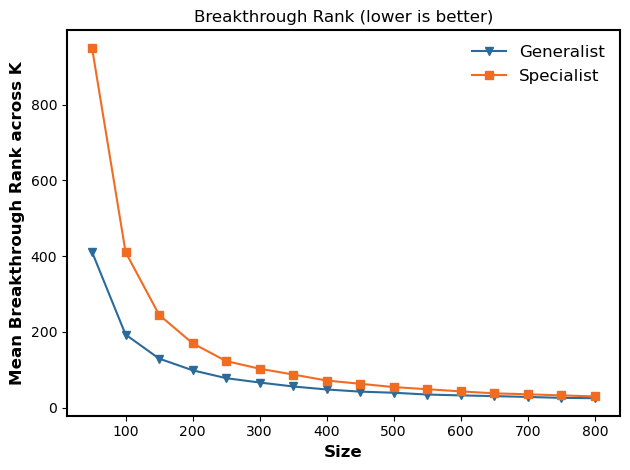

In [53]:
# Figure: Mean Breakthrough Rank (lower is better) across K
g_mean_across_K = dv_data["G"]["breakthrough_rank"].mean(axis=1)
s_mean_across_K = dv_data["S"]["breakthrough_rank"].mean(axis=1)

fig, ax = plt.subplots()

ax.spines["left"].set_linewidth(1.5)
ax.spines["right"].set_linewidth(1.5)
ax.spines["top"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)

ax.plot(agent_num_list, g_mean_across_K, "v-", label="Generalist", color=nature_blue)
ax.plot(agent_num_list, s_mean_across_K, "s-", label="Specialist", color=nature_orange)

ax.set_xlabel("Size", fontweight="bold", fontsize=12)
ax.set_ylabel("Mean Breakthrough Rank across K", fontweight="bold", fontsize=12)
ax.set_title("Breakthrough Rank (lower is better)")
ax.legend(frameon=False, fontsize=12)

fig.tight_layout()
fig.savefig(
    results_folder / "GS_independent_breakthrough_rank_mean_across_K.png",
    transparent=True,
    dpi=300,
)
plt.show()